In [1]:
import os
import sys

# Add the parent directory to the system path
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
from numpy.polynomial.chebyshev import Chebyshev
import json
import pprint as pp
from util.filehandler import load_gp_model
from util.gaussian_processes import sample_gp_model
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [100]:
def fit_chebyshev_approximation(
    gp_result: dict,
    degree: int = 10,
    n_grid_points: int = 200,
    n_samples: int = 50,
    log_transform: bool = False
) -> dict:
    """
    Fit Chebyshev polynomial approximation to GP model.
    Handles both single-task and multi-task GP models.
    
    Args:
        gp_result: Result dict from fit_gp_model
        degree: Chebyshev polynomial degree (higher = more flexible)
        n_grid_points: Number of points to evaluate GP on
        n_samples: Number of samples for computing mean/std
        log_transform: Whether to apply log transform
    
    Returns:
        Dict with Chebyshev coefficients and metadata
    """
    depth_min, depth_max = gp_result['depth_range']
    depth_grid = np.linspace(depth_min, depth_max, n_grid_points)
    num_tasks = gp_result['num_tasks']
    
    # Generate samples from GP
    samples = sample_gp_model(
        gp_result, depth_grid, 
        n_samples=n_samples, 
        log_transform=False
    )
    
    # samples shape: (n_samples, n_grid_points) for single-task
    #              or (n_samples, n_grid_points, num_tasks) for multi-task
    
    # Normalize to always have 3D shape
    if num_tasks == 1:
        samples = samples.reshape(n_samples, n_grid_points, 1)
    
    # Compute statistics across samples for each task
    mean_values = samples.mean(axis=0)  # shape: (n_grid_points, num_tasks)
    std_values = samples.std(axis=0)    # shape: (n_grid_points, num_tasks)
    
    # Fit separate Chebyshev polynomial for each task
    mean_coeffs = []
    std_coeffs = []
    
    for task_idx in range(num_tasks):
        mean_cheb = Chebyshev.fit(
            depth_grid, mean_values[:, task_idx], 
            deg=degree, domain=[depth_min, depth_max]
        )
        std_cheb = Chebyshev.fit(
            depth_grid, std_values[:, task_idx], 
            deg=degree, domain=[depth_min, depth_max]
        )
        mean_coeffs.append(mean_cheb.coef.tolist())
        std_coeffs.append(std_cheb.coef.tolist())
    
    return {
        'mean_coeffs': mean_coeffs,  # List of coefficient arrays, one per task
        'std_coeffs': std_coeffs,    # List of coefficient arrays, one per task
        'domain': [float(depth_min), float(depth_max)],
        'degree': degree,
        'n_grid_points': n_grid_points,
        'n_samples': n_samples,
        'log_transform': log_transform,
        'num_tasks': num_tasks
    }


def save_chebyshev_approximation(cheb_params: dict, filepath: str) -> None:
    """
    Save Chebyshev parameters to JSON file.
    
    Args:
        cheb_params: Dict from fit_chebyshev_approximation
        filepath: Path to save JSON file
    """
    with open(filepath, 'w') as f:
        json.dump(cheb_params, f, indent=2)


def load_chebyshev_approximation(filepath: str) -> dict:
    """
    Load Chebyshev parameters from JSON file.
    
    Args:
        filepath: Path to JSON file
    
    Returns:
        Dict with Chebyshev parameters
    """
    with open(filepath, 'r') as f:
        return json.load(f)


def fast_chebyshev_evaluate(
    cheb_params: dict,
    x_new: np.ndarray,
    return_std: bool = True
):
    """
    Fast evaluation using pre-fit Chebyshev polynomials.
    
    Args:
        cheb_params: Dict from fit_chebyshev_approximation
        x_new: Depth values to evaluate at
        return_std: Whether to also return std values
    
    Returns:
        For single-task: mean array, or (mean, std) if return_std=True
        For multi-task: mean array of shape (len(x_new), num_tasks)
    """
    domain = cheb_params['domain']
    num_tasks = cheb_params['num_tasks']
    x_new = np.asarray(x_new)
    
    # Evaluate all tasks
    mean = np.zeros((len(x_new), num_tasks))
    
    for task_idx in range(num_tasks):
        mean_cheb = Chebyshev(cheb_params['mean_coeffs'][task_idx], domain=domain)
        mean[:, task_idx] = mean_cheb(x_new)
    
    if not return_std:
        # Return 1D for single-task, 2D for multi-task
        return mean.squeeze()
    
    std = np.zeros((len(x_new), num_tasks))
    for task_idx in range(num_tasks):
        std_cheb = Chebyshev(cheb_params['std_coeffs'][task_idx], domain=domain)
        std[:, task_idx] = np.maximum(std_cheb(x_new), 1e-6)
    
    # Return shapes consistent with input dimensionality
    if cheb_params.get('log_transform', False):
        variance = std ** 2
        mean_original = np.exp(mean + variance/2)
        std_original = np.sqrt((np.exp(variance) - 1) * np.exp(2 * mean + variance))
        return mean_original, std_original
    return mean.squeeze(), std.squeeze()


def fast_chebyshev_sample(
    cheb_params: dict,
    x_new: np.ndarray,
    n_samples: int = 1
) -> np.ndarray:
    """
    Fast sampling using pre-fit Chebyshev polynomials.
    
    Args:
        cheb_params: Dict from fit_chebyshev_approximation
        x_new: Depth values to sample at
        n_samples: Number of samples to generate
    
    Returns:
        For single-task: array of shape (n_samples, len(x_new))
        For multi-task: array of shape (n_samples, len(x_new), num_tasks)
    """
    x_new = np.asarray(x_new)
    mean, std = fast_chebyshev_evaluate(cheb_params, x_new, return_std=True)
    
    num_tasks = cheb_params['num_tasks']
    
    # Generate samples: mean + std * noise
    if num_tasks == 1:
        samples = mean + std * np.random.randn(n_samples, len(x_new))
    else:
        # mean, std have shape (len(x_new), num_tasks)
        samples = mean + std * np.random.randn(n_samples, len(x_new), num_tasks)
    
    # if cheb_params.get('log_transform', False):
    #     samples = np.exp(samples)
    
    return samples

In [42]:
shale_model = load_gp_model("../data/models/shale_pl_vp_vs.pth")
depth_min, depth_max = shale_model['depth_range']
shale_dict = fit_chebyshev_approximation(shale_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(shale_dict, "../data/grids/chebyshev/shale_pl_vp_vs.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
brine_model = load_gp_model("../data/models/brine_pl_vp_vs.pth")
depth_min, depth_max = brine_model['depth_range']
brine_dict = fit_chebyshev_approximation(brine_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(brine_dict, "../data/grids/chebyshev/brine_pl_vp_vs.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [44]:
oil_model = load_gp_model("../data/models/oil_pl_vp_vs.pth")
depth_min, depth_max = oil_model['depth_range']
oil_dict = fit_chebyshev_approximation(oil_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(oil_dict, "../data/grids/chebyshev/oil_pl_vp_vs.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [46]:
gas_model = load_gp_model("../data/models/gas_pl_vp.pth")
depth_min, depth_max = gas_model['depth_range']
gas_dict = fit_chebyshev_approximation(gas_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(gas_dict, "../data/grids/chebyshev/gas_pl_vp.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [109]:
cheb_params = load_chebyshev_approximation('../data/grids/chebyshev/gas_pl_vp.json')
# cheb_params['log_transform'] = False
depth_min, depth_max = 0, 4000
depths = np.arange(depth_min, depth_max, 1)
samples = fast_chebyshev_sample(cheb_params, depths, n_samples=1)
mean, std = fast_chebyshev_evaluate(cheb_params, depths)

In [111]:
mask = (depths >= 1250) & (depths <= 3900)
mean[mask].shape

(2651, 2)

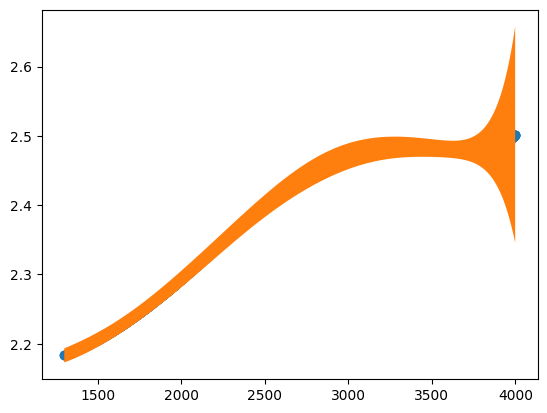

In [103]:
plt.scatter(depths, mean[:,0])
plt.fill_between(depths, mean[:,0] - std[:,0], mean[:,0] + std[:,0])

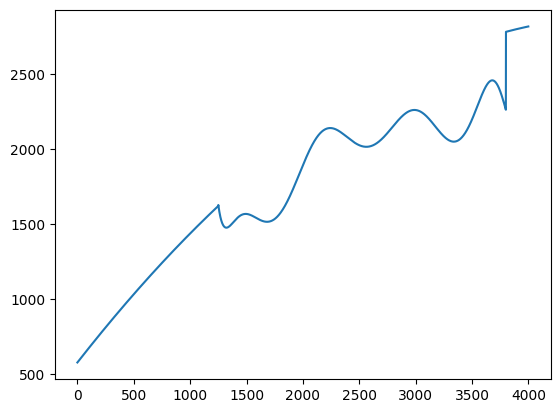

In [54]:
from synthoseis.rockphysics.rpm_tagilsk import RPMTagilsk
test = RPMTagilsk('lala')
depths = np.arange(0, 4000, 1)
shales = test.calc_shale_properties(depths, depths, depths)
plt.plot(shales.vs)